In this notebook, you will learn to how to fit a parametric models to describe the orientation tuning of a neuron in the mouse visual cortex and the position tuning of neurons in the hippocampus.

 # Download the data

Let's start with the visual neuron.

(1) Download the datafile called `visual_neuron.npy` from elearning (week 5) to your computer.

(2) Run the code cell below. It will open a file picker GUI using which you can manually select and load that `npy` datafile by clicking `Choose Files` and navigating to the folder to which you downloaded the file. You should see the file being loaded in google colab. You're all set to move on!

In [13]:
from google.colab import files
uploaded = files.upload()

Saving visual_neuron.npy to visual_neuron (1).npy


# Data description

The data is a three-dimensional numpy array:

*   The first dimension of the data corresponds to the 18 conditions tested in the experiment: in the first 16 sets of experiments, the angle of the grating was oriented and moved at a 0° angle, then a 22.5° angle, then a 45° angle, and so on in steps of 22.5° all the way around a circle (up to 337.5°). In the final two experiments, a blank screen of the same average brightness (luminance) of the gratings was presented. These final two experiments were control experiments to test the responsiveness of the neuron to the same average light level in the absence of a grating.


*   The second dimension corresponds to the spike train values over time, where a value of 1 indicates that there was a spike at this time, and a value of 0 indicates no spike. The experiment ran for 3500 ms, with data gathered every 1 ms. At t=0, the oriented grating was turned on; at t=500 ms the grating started moving (with orientation and direction specified by the first dimension of this data set; gratings were always oriented 3 perpendicular to the direction of movement), and at t=2500 ms the stimulus was turned off.


*   The third dimension of the data corresponds to the 30 trials that were run for each condition. That is, for each direction of movement, they took 30 separate spike train recordings.

# Load the data

Let's load the data and make sure the shape of the data matches the description above.

In [14]:
import numpy as np
spikes = np.load('visual_neuron.npy')

# Create useful variables

In [15]:
### load size of each dimension
n_conditions, n_timepoints, n_trials = spikes.shape

### set up useful variables
n_controls = 2                                    # number of control experiments with no grating
dt = 1                                            # spacing between sampled time points [ms]
t_On = 0                                          # time stimulus turns on [ms]
t_Move = 500                                      # time stimulus begins moving [ms]
t_Off = 2500                                      # time stimulus turns off [ms]
n_angles = n_conditions - n_controls              # number of angles tested
t_vect = np.arange(t_On, n_timepoints * dt, dt)   # vector of time points useful for plotting

# Plot the tuning function

In [16]:
# Convert time to index
start_idx = int(t_Move / dt)
end_idx   = int(t_Off  / dt)

# Sum spikes across trials during motion period
tuning_counts_matrix = np.sum(spikes[:, start_idx:end_idx, :], axis=2)

# Sum across time
tuning_counts_vect = np.sum(tuning_counts_matrix, axis=1)

# Convert to average firing rate (Hz)
bin_width_s = dt / 1000
tuning_ave_rate_vect = tuning_counts_vect / ((t_Off - t_Move) * n_trials * bin_width_s)

# Orientation vector
delta_theta = 360 / n_angles
orientation_vect = np.arange(n_angles) * delta_theta

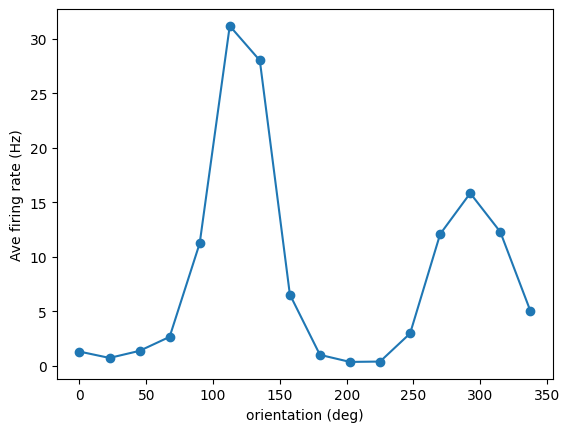

In [17]:
from matplotlib import pyplot as plt
plt.figure()
plt.plot(orientation_vect, tuning_ave_rate_vect[:n_angles], 'o-')
plt.xlabel('orientation (deg)')
plt.ylabel('Ave firing rate (Hz)')
plt.show()

Non-Monotomic function: Examples of functions are Sin, Cos, Gaussian
Here we see a mixture of 2 gaussians.

Gaussian is commonly described in probability.

Gaussian function: Is just a function that emulates a bell curve. But now has an additional degree of freedom (Amplitude). (Fitting 3 parameters)

Gaussian Distribution: Area under curve is 1, proportionality constant MUST be set to work.

As this a mixture of 2 gaussians we need to fit 6 parameters + 1

f(x) = A1 * e + A2 * e

However this function is a positive only x-axis, gaussians are -inf to inf for x-axis. Gaussian doesn't wrap around, so we instead need a function that does wrap around (1 degree vs 360 degree is the same).

# Fit a model to the tuning function

Now let us fit a model to describe the shape of this neuron's tuning function. This neuron seems to have two preferred orientations. We see two Gaussian-like bumps that differ in amplitude, location, and width. So it is reasonable to try to describe it as a mixture of two gaussians. But gaussian functions work on variables that assume values in the range (-$\infty$, $\infty$). Orientation is a circular variable in the range ($0$, $2\pi$) so we will instead fit von mises function, which looks kind of like a gaussian but works on circular variables.

Von-Mises function.

# The model

$$
r(x) = b + A_1 e^{\kappa_1 \cos(x - \mu_1)} + A_2 e^{\kappa_2 \cos(x - \mu_2)}
$$

where

- $r(x)$ is the firing rate at orientation $x$
- $b$ is the baseline firing rate
- $A_1, A_2$ are the amplitudes of the two tuning components
- $\kappa_1, \kappa_2$ control the tuning widths
- $\mu_1, \mu_2$ control the location

First thing in fitting models is a Cost Function

Figure out if it's linear or not.
Linear functions have 2 properties:
1. f(kx) = kf(x)
2. f(x+y) = f(x) + f(y)

In [18]:
from scipy.optimize import curve_fit #To call two_von_mises

# Remove control conditions
y = tuning_ave_rate_vect[:n_angles]

# Orientation vector in degrees
delta_theta = 360 / n_angles
x_deg = np.arange(n_angles) * delta_theta
x_rad = np.deg2rad(x_deg)

# tuning model (mixture of two von-Mises)
def two_von_mises(x, A1, k1, mu1, A2, k2, mu2, b):
    return b + A1*np.exp(k1*np.cos(x-mu1)) + A2*np.exp(k2*np.cos(x-mu2))

# initial guess
p0 = [5, 1, 0, 5, 1, np.pi, 0]

params, _ = curve_fit(two_von_mises, x_rad, y, p0=p0, maxfev=10000)

# Curve for plotting
x_fit_deg = np.linspace(0, 360, 500)
x_fit_rad = np.deg2rad(x_fit_deg)
y_fit = two_von_mises(x_fit_rad, *params)

print("Fitted parameters:")
print(f"A1={params[0]:.3f}, k1={params[1]:.3f}, mu1={np.rad2deg(params[2]):.1f} deg")
print(f"A2={params[3]:.3f}, k2={params[4]:.3f}, mu2={np.rad2deg(params[5]):.1f} deg")
print(f"baseline={params[6]:.3f}")

Fitted parameters:
A1=0.123, k1=4.871, mu1=-65.9 deg
A2=0.009, k2=8.206, mu2=121.1 deg
baseline=0.481


Now let's plot the model on top of data.

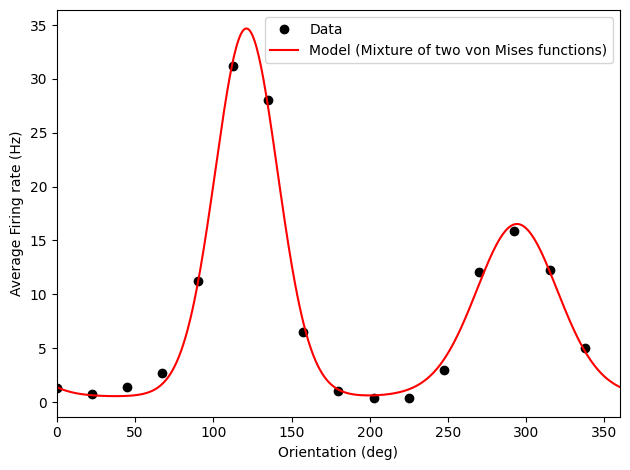

In [19]:
# Plot
plt.figure()
plt.plot(x_deg, y, 'ko', label='Data')
plt.plot(x_fit_deg, y_fit, 'r-', label='Model (Mixture of two von Mises functions)')
plt.xlabel('Orientation (deg)')
plt.ylabel('Average Firing rate (Hz)')
plt.xlim(0, 360)
plt.legend()
plt.tight_layout()
plt.show()

# Download the data

Now let's take a look at hippocampal neurons.

(1) Download the datafile called `hippocampal_neurons.npy` and `mouse_position,npy` from elearning (week 6) to your computer.

(2) Run the code cell below. It will open a file picker GUI using which you can manually select and load both `npy` datafiles by clicking `Choose Files` and navigating to the folder to which you downloaded the files. You should see the file being loaded in google colab. You're all set to move on!

In [20]:
from google.colab import files
uploaded = files.upload()

Saving hippocampal_neurons.npy to hippocampal_neurons (1).npy
Saving mouse_position.npy to mouse_position (1).npy


# Load the data

In [21]:
response = np.load('hippocampal_neurons.npy', allow_pickle=True)
position = np.load('mouse_position.npy')

# Create useful variables

In [22]:
[n_timepoints, n_neurons] = np.shape(response)
pos_min, pos_max = np.nanmin(position), np.nanmax(position)
n_bins = 25           # number of spatial bins

# Plot the tuning function

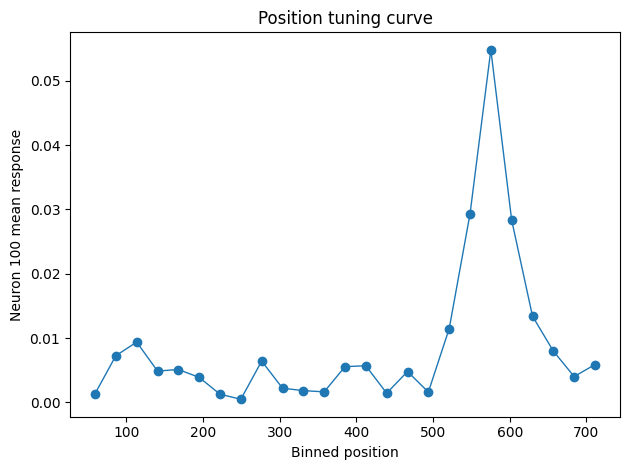

In [38]:
# Pick a neuron
neuron_idx = 100 #np.random.randint(n_neurons)
r = response[:, neuron_idx]

# Bin position
edges = np.linspace(pos_min, pos_max, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

# Assign each timepoint to a bin
bin_idx = np.digitize(position, edges) - 1  # 0, 1, ..., n_bins-1
validbins = (bin_idx >= 0) & (bin_idx < n_bins)
bin_idx = bin_idx[validbins]
r_valid = r[validbins]

# Compute mean response per bin (tuning curve)
sum_r = np.bincount(bin_idx, weights=r_valid, minlength=n_bins)
cnt = np.bincount(bin_idx, minlength=n_bins)
mean_r = sum_r / cnt

# Plot
plt.figure()
plt.plot(centers, mean_r, marker='o', linewidth=1)
plt.xlabel('Binned position')
plt.ylabel(f'Neuron {neuron_idx} mean response')
plt.title('Position tuning curve')
plt.tight_layout()
plt.show()

Position can be negative, whereas earlier position is circular and can never be negative, a negative degree is equal to some positive degree

Even with a goal of interptretable, modeling is useful. (Gassuian is much more interpretable than polynomials)

# Fit a model to the tuning function

Most neurons seem to have just one preferred position and it kind of looks like a Gaussian bump. So let's fit a Gaussian function.

# The model

$$
r(x) = b + A \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

where

- $r(x)$ is the firing rate at position $x$
- $b$ is the baseline firing rate
- $A$ is the amplitude of the tuning curve
- $\mu$ is the preferred position
- $\sigma$ controls the width of the tuning

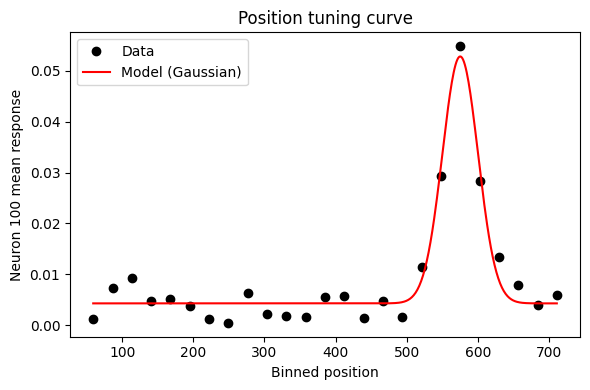

Fitted parameters:
A=0.048, mu=575.307, sigma=25.0
baseline=0.004


In [39]:
# Pick a neuron
neuron_idx = 100 #np.random.randint(n_neurons)
r = response[:, neuron_idx]

# Bin position
edges = np.linspace(pos_min, pos_max, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

# Assign each timepoint to a bin
bin_idx = np.digitize(position, edges) - 1
validbins = (bin_idx >= 0) & (bin_idx < n_bins)
bin_idx = bin_idx[validbins]
r_valid = r[validbins]

# Compute mean response per bin
sum_r = np.bincount(bin_idx, weights=r_valid, minlength=n_bins)
cnt = np.bincount(bin_idx, minlength=n_bins)
mean_r = sum_r / cnt

# Keep only bins that have data
valid = cnt > 0
x = centers[valid]
y = mean_r[valid]

# tuning model (Gaussian)
def gaussian(x, A, mu, sigma, b):
    return b + A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Initial guess
p0 = [0.01, 400, 100, 0]

# Fit
params, _ = curve_fit(gaussian, x, y, p0=p0)

# Smooth curve for plotting
x_fit = np.linspace(np.min(x), np.max(x), 500)
y_fit = gaussian(x_fit, *params)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'ko', label='Data')
plt.plot(x_fit, y_fit, 'r-', label='Model (Gaussian)')
plt.xlabel('Binned position')
plt.ylabel(f'Neuron {neuron_idx} mean response')
plt.title('Position tuning curve')
plt.legend()
plt.tight_layout()
plt.show()

print("Fitted parameters:")
print(f"A={params[0]:.3f}, mu={params[1]:.3f}, sigma={params[2]:.1f}")
print(f"baseline={params[3]:.3f}")

/tmp/ipykernel_178/2403485433.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(gaussian, x, y, p0=p0, maxfev=10000)


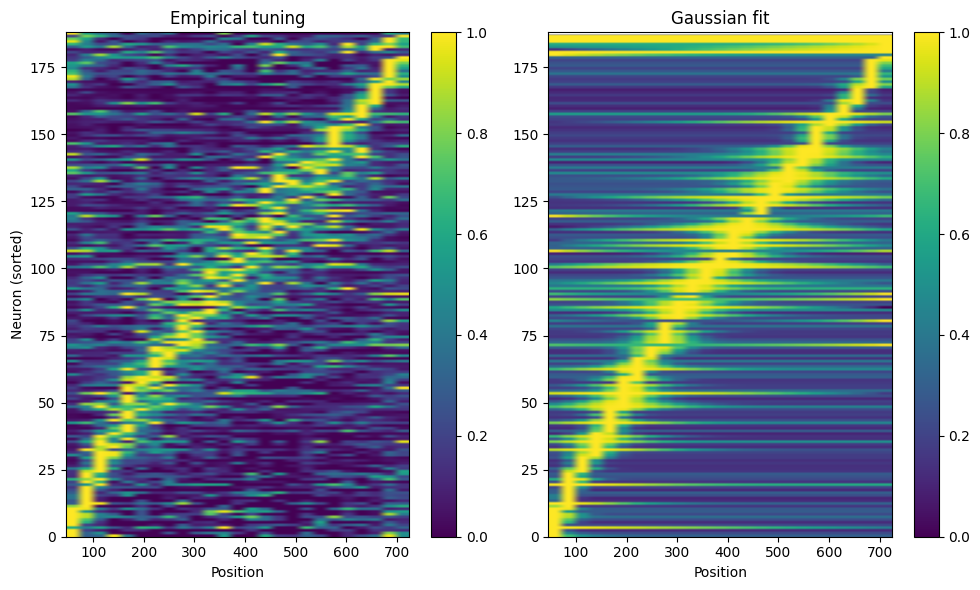

In [40]:
# Gaussian model
def gaussian(x, A, mu, sigma, b):
    return b + A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Store empirical tuning, fitted tuning, and preferred position
empirical_tuning = np.zeros((n_neurons, n_bins))
fitted_tuning = np.zeros((n_neurons, n_bins))
pref_pos = np.zeros(n_neurons)

for neuron_idx in range(n_neurons):
    r = response[:, neuron_idx]
    r_valid = r[validbins]

    # Compute mean response per bin
    sum_r = np.bincount(bin_idx, weights=r_valid, minlength=n_bins)
    cnt = np.bincount(bin_idx, minlength=n_bins)
    mean_r = sum_r / cnt

    # Keep only bins that have data
    valid = cnt > 0
    x = centers[valid]
    y = mean_r[valid]

    # Initial guess
    p0 = [np.max(y) - np.min(y), x[np.argmax(y)], np.std(x), np.min(y)]

    # Fit Gaussian
    try:
        params, _ = curve_fit(gaussian, x, y, p0=p0, maxfev=10000)
        y_fit = gaussian(centers, *params)
        pref_pos[neuron_idx] = params[1]
    except RuntimeError:
        y_fit = np.full(n_bins, np.nan)
        pref_pos[neuron_idx] = np.inf

    # Normalize each row by its max
    empirical_tuning[neuron_idx] = mean_r / np.max(mean_r)
    fitted_tuning[neuron_idx] = y_fit / np.max(y_fit)

# Sort neurons by preferred position
sort_idx = np.argsort(pref_pos)
empirical_tuning = empirical_tuning[sort_idx]
fitted_tuning = fitted_tuning[sort_idx]

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

im0 = ax[0].imshow(empirical_tuning, aspect='auto', origin='lower',
                   extent=[pos_min, pos_max, 0, n_neurons])
ax[0].set_xlabel('Position')
ax[0].set_ylabel('Neuron (sorted)')
ax[0].set_title('Empirical tuning')
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(fitted_tuning, aspect='auto', origin='lower',
                   extent=[pos_min, pos_max, 0, n_neurons])
ax[1].set_xlabel('Position')
ax[1].set_title('Gaussian fit')
plt.colorbar(im0, ax=ax[1])

plt.tight_layout()
plt.show()